# Tutorial 4 — Composing a Biological Model

The previous tutorials showed the mechanics — processes, steps, wiring, emitters. This one
puts them to work on real biology and highlights two things process-bigraph is *for*:

1. **Composition.** A cell is not one equation; it is many mechanisms sharing molecular
   state. In process-bigraph each mechanism is an independent `Process`, and a `Composite`
   wires them over the same stores. You add biology by adding a process — not by editing a
   monolithic model.
2. **Biological semantics in the types.** A port is not a bare `float`. It carries the
   *unit* of the quantity it moves — `nanomolar`, `1/second` — so the model documents its
   own biology and the schema is introspectable.

Our running example is the **central dogma**: a gene is *transcribed* into mRNA, mRNA is
*translated* into protein, and both species *decay*. We will build it from four small
processes, watch it reach steady state, then add **negative autoregulation** — the protein
repressing its own gene — just by wiring one more edge.

$$\frac{d[\text{mRNA}]}{dt} = k_{tx} - k_{m}\,[\text{mRNA}] \qquad
  \frac{d[\text{protein}]}{dt} = k_{tl}\,[\text{mRNA}] - k_{p}\,[\text{protein}]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from process_bigraph import allocate_core
from process_bigraph.composite import Process, Composite
from process_bigraph.emitter import emitter_from_wires, gather_emitter_results

core = allocate_core()

skipping `process_bigraph.server.start` (missing optional dep `fire`)


## 1. Biological semantics in the types

A port's type can carry a **unit**. In bigraph-schema a numeric type is a `float` with an
optional `_units` field — a pint-parseable string.

It means a unit string that the Python Pint library understands, such as:
"nanomolar"
"second"
"1/second"
"meter/second"
"milligram/liter"

We name the two quantities our model
moves, once, and reuse them everywhere:

- `CONC` — a molecular **concentration**, in `nanomolar`,
- `RATE` — a first-order **rate constant**, in `1/second`.

Declaring ports and config with these instead of bare `float` makes each process
self-describing: `interface()` reports not just *that* `mRNA` is a number but that it is a
concentration in nanomolar.

> **Two levels of unit typing.** `_units` on a `float` is *schema metadata* — the runtime
> value stays a plain `float`, and the unit documents intent and is available for
> introspection and downstream checking. bigraph-schema also has a heavier `quantity` type
> whose runtime values are real `pint.Quantity` objects (With two fields: magnitude and units and a conversion method with`.to(...)`, dimensional
> arithmetic). This tutorial uses the lightweight `_units` form; reach for `quantity` when
> you need the engine to carry and convert units at runtime.

In [2]:
# Biological port/config types — declared once, reused across every process.
CONC = {'_type': 'float', '_units': 'nanomolar'}   # a molecular concentration
RATE = {'_type': 'float', '_units': '1/second'}    # a first-order rate constant
FLUX = {'_type': 'float', '_units': 'nanomolar/second'}  # a zero-order synthesis rate


class Transcription(Process):
    """Gene -> mRNA at a constant rate (zero-order synthesis)."""
    config_schema = {'k_tx': FLUX}
    def inputs(self):  return {}                      # constitutive: reads nothing
    def outputs(self): return {'mRNA': CONC}
    def update(self, state, interval):
        return {'mRNA': self.config['k_tx'] * interval}


tx = Transcription(config={'k_tx': 5.0}, core=core)
print('Transcription outputs:', tx.interface()['outputs'])   # note the unit travels with the port

Transcription outputs: {'mRNA': {'_type': 'float', '_units': 'nanomolar'}}


The output port reports `{'mRNA': {'_type': 'float', '_units': 'nanomolar'}}` — the biology
is in the type, not just in a comment.

## 2. Three more mechanisms

Each biological mechanism is one small `Process`. **Translation** reads the mRNA
concentration and produces protein in proportion to it. **Decay** is first-order removal of
*one* species — and because it is generic (a species `x` and a rate `k_deg`), we write it
once and instantiate it twice: for mRNA and for protein. That reuse is the payoff of
treating a mechanism as a parameterized, wireable unit.

In [3]:
class Translation(Process):
    """mRNA -> protein, proportional to mRNA concentration."""
    config_schema = {'k_tl': RATE}
    def inputs(self):  return {'mRNA': CONC}
    def outputs(self): return {'protein': CONC}
    def update(self, state, interval):
        return {'protein': self.config['k_tl'] * state['mRNA'] * interval}


class Decay(Process):
    """First-order decay of one species — reused for mRNA and for protein."""
    config_schema = {'k_deg': RATE, 'species': 'string'}
    def inputs(self):  return {'x': CONC}
    def outputs(self): return {'x': CONC}
    def update(self, state, interval):
        return {'x': -self.config['k_deg'] * state['x'] * interval}


for cls in (Transcription, Translation, Decay):
    core.register_link(cls.__name__, cls)
print('registered:', [c.__name__ for c in (Transcription, Translation, Decay)])

registered: ['Transcription', 'Translation', 'Decay']


## 3. Compose the central dogma

A `Composite` wires the four processes over two shared stores, `mRNA` and `protein`. Note
what shares state: **transcription** *adds* to `mRNA` while **mRNA-decay** *subtracts* from
it — both target the same store, and their per-step contributions simply sum. That is
composition: no process knows about the others; they interact only through the stores they
share. An `emitter` records the two concentrations over time.

Each process advances on its own `interval` (0.1 s here — small enough for the explicit
Euler step each `update` performs to track the ODE).

In [4]:
# Rate constants
k_tx, k_tl, k_mdeg, k_pdeg = 5.0, 2.0, 0.2, 0.05


def central_dogma(transcription_edge):
    """Assemble the composite from a transcription edge + the shared machinery."""
    return {
        'mRNA': 0.0, 'protein': 0.0,
        'transcription': transcription_edge,
        'mRNA_decay': {
            '_type': 'process', 'address': 'local:Decay',
            'config': {'k_deg': k_mdeg, 'species': 'mRNA'}, 'interval': 0.1,
            'inputs': {'x': ['mRNA']}, 'outputs': {'x': ['mRNA']}},
        'translation': {
            '_type': 'process', 'address': 'local:Translation',
            'config': {'k_tl': k_tl}, 'interval': 0.1,
            'inputs': {'mRNA': ['mRNA']}, 'outputs': {'protein': ['protein']}},
        'protein_decay': {
            '_type': 'process', 'address': 'local:Decay',
            'config': {'k_deg': k_pdeg, 'species': 'protein'}, 'interval': 0.1,
            'inputs': {'x': ['protein']}, 'outputs': {'x': ['protein']}},
        'emitter': emitter_from_wires(
            {'time': ['global_time'], 'mRNA': ['mRNA'], 'protein': ['protein']}),
    }


constitutive_tx = {
    '_type': 'process', 'address': 'local:Transcription',
    'config': {'k_tx': k_tx}, 'interval': 0.1,
    'inputs': {}, 'outputs': {'mRNA': ['mRNA']}}

sim = Composite({'state': central_dogma(constitutive_tx)}, core=core)
sim.run(80.0)

records = gather_emitter_results(sim)[('emitter',)]
t   = np.array([r['time'] for r in records])
mrna = np.array([r['mRNA'] for r in records])
prot = np.array([r['protein'] for r in records])
print(f'{len(records)} timepoints recorded')

801 timepoints recorded


The steady state is analytic — a good check on the composed model:

$$[\text{mRNA}]_{ss} = \frac{k_{tx}}{k_m} \qquad
  [\text{protein}]_{ss} = \frac{k_{tl}}{k_p}\,[\text{mRNA}]_{ss}$$

mRNA    final =   25.00 nM   (analytic 25.00)
protein final =  975.82 nM   (analytic 1000.00)


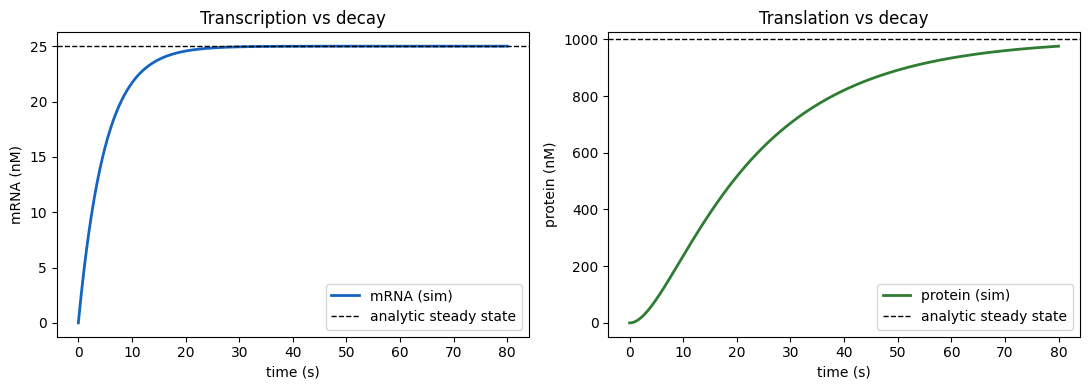

In [5]:
mrna_ss = k_tx / k_mdeg
prot_ss = k_tl * mrna_ss / k_pdeg
print(f'mRNA    final = {mrna[-1]:7.2f} nM   (analytic {mrna_ss:.2f})')
print(f'protein final = {prot[-1]:7.2f} nM   (analytic {prot_ss:.2f})')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(t, mrna, color='#1565c0', lw=2, label='mRNA (sim)')
a1.axhline(mrna_ss, ls='--', color='k', lw=1, label='analytic steady state')
a1.set_xlabel('time (s)'); a1.set_ylabel('mRNA (nM)'); a1.set_title('Transcription vs decay'); a1.legend()
a2.plot(t, prot, color='#2e7d32', lw=2, label='protein (sim)')
a2.axhline(prot_ss, ls='--', color='k', lw=1, label='analytic steady state')
a2.set_xlabel('time (s)'); a2.set_ylabel('protein (nM)'); a2.set_title('Translation vs decay'); a2.legend()
plt.tight_layout(); plt.show()

Both species climb to their predicted steady states — mRNA fast (it turns over quickly),
protein slowly (it is more stable). The composed system reproduces the analytic result
exactly, with no ODE ever written down as a single block: each mechanism contributed its
own term to the shared stores.

## 4. Add regulation by adding a wire

Real genes are regulated. A classic motif is **negative autoregulation**: the protein
represses its own gene, so transcription slows as protein accumulates. In our terms this is
one new mechanism — a transcription process that *reads the protein store* and sets its
rate by a Hill function:

$$k_{tx}(\text{protein}) = \frac{V_{max}}{1 + (\text{protein}/K)^{n}}$$

Crucially, **nothing else changes**. We swap the transcription edge for a regulated one
that adds a `protein` input wire; translation, decay, and the stores are untouched. Adding
biology means adding a process and a wire.

In [6]:
class RegulatedTranscription(Process):
    """Negative autoregulation: the protein represses its own transcription (Hill)."""
    config_schema = {'vmax': FLUX, 'K': CONC, 'n': 'float'}
    def inputs(self):  return {'protein': CONC}          # <- the new feedback wire
    def outputs(self): return {'mRNA': CONC}
    def update(self, state, interval):
        p, K, n = state['protein'], self.config['K'], self.config['n']
        rate = self.config['vmax'] / (1.0 + (p / K) ** n)
        return {'mRNA': rate * interval}


core.register_link('RegulatedTranscription', RegulatedTranscription)

regulated_tx = {
    '_type': 'process', 'address': 'local:RegulatedTranscription',
    'config': {'vmax': 20.0, 'K': 200.0, 'n': 2.0}, 'interval': 0.1,
    'inputs': {'protein': ['protein']},           # reads the product it represses
    'outputs': {'mRNA': ['mRNA']}}

sim_reg = Composite({'state': central_dogma(regulated_tx)}, core=core)
sim_reg.run(80.0)
rec_reg = gather_emitter_results(sim_reg)[('emitter',)]
t_r  = np.array([r['time'] for r in rec_reg])
prot_r = np.array([r['protein'] for r in rec_reg])
print(f'autoregulated protein settles near {prot_r[-1]:.0f} nM '
      f'(vs {prot[-1]:.0f} nM constitutive)')

autoregulated protein settles near 518 nM (vs 976 nM constitutive)


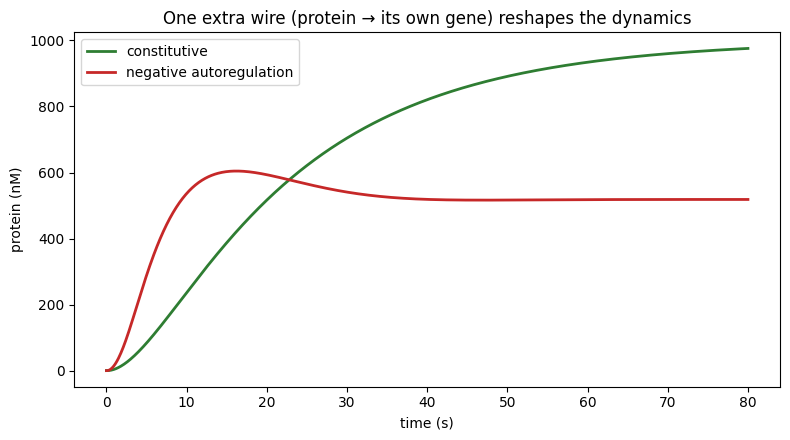

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t,   prot,   color='#2e7d32', lw=2, label='constitutive')
ax.plot(t_r, prot_r, color='#c62828', lw=2, label='negative autoregulation')
ax.set_xlabel('time (s)'); ax.set_ylabel('protein (nM)')
ax.set_title('One extra wire (protein → its own gene) reshapes the dynamics')
ax.legend()
plt.tight_layout(); plt.show()

The autoregulated protein rises quickly at first — the gene is fully on while protein is
low — then brakes itself to a lower, tightly held level as repression kicks in. This
faster-responding, more homeostatic behavior is exactly why negative autoregulation is one
of the most common motifs in real gene networks. We obtained it by composing one more
mechanism onto an unchanged model.

## Recap

| idea | in this tutorial |
|---|---|
| a mechanism is a `Process` | `Transcription`, `Translation`, `Decay`, `RegulatedTranscription` |
| biology lives in the *type* | ports typed `CONC` (`nanomolar`) / rates `RATE` (`1/second`), introspectable via `interface()` |
| processes interact through shared stores | transcription **+** and decay **−** both target `mRNA`; their contributions sum |
| reuse a mechanism by parameterizing it | one `Decay` class, instantiated for mRNA and protein |
| add biology by adding a process + wire | swapping in `RegulatedTranscription` (a `protein` input) adds feedback with nothing else touched |

### Where to go next
- **Tutorial 1** — the mechanics (processes, steps, ports, composites, emitters) in depth.
- **Tutorial 2** — wrapping an existing ODE solver (`odeint`) as a `Process`, if you would
  rather integrate stiff kinetics than take explicit Euler steps.
- **[`doc/architecture.md`](https://github.com/vivarium-collective/process-bigraph/blob/main/doc/architecture.md)**
  — how composites nest, the higher-order DAG, and the laws the framework follows.

Everything here is *local* biology composed by hand. When you want to organize many such
models into studies, cache expensive results, and drive them from a UI, that is the job of
the **[Vivarium Workbench](https://github.com/vivarium-collective/vivarium-workbench)** —
which runs process-bigraph composites like this one underneath.